# Experiment on CNN

In [6]:
import kagglehub

path = kagglehub.dataset_download("agrigorev/clothing-dataset-full")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\cpick\.cache\kagglehub\datasets\agrigorev\clothing-dataset-full\versions\1


## Filter out corrupted images

In [7]:
import os

num_skipped = 0
valid_image = []  # Store names of deleted files

for folder_name in ("images_compressed", "images_original"):
    folder_path = os.path.join(path, folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)
        else:
            valid_image.append(fname.lstrip("0").removesuffix(".jpg"))

print(f"Deleted {num_skipped} images.")

Deleted 0 images.


## Load the images, remove the corrupted one

In [8]:
import torch
import torchvision.ops as ops
import numpy as np
import pandas as pd
from PIL import Image

def load_image(image_id):
    image_path = f"{path}/images_compressed/{image_id}.jpg"
    image = Image.open(image_path)
    resized_imge = image.resize((224, 224))
    return np.array(resized_imge, )

df = pd.read_csv(path + "/images.csv", na_values=["Not sure"])
df = df.dropna()
df = df[df['image'].isin(valid_image)].reset_index(drop=True)
df['image_data'] = df['image'].apply(load_image)



## Show the first image to see if the loading worked

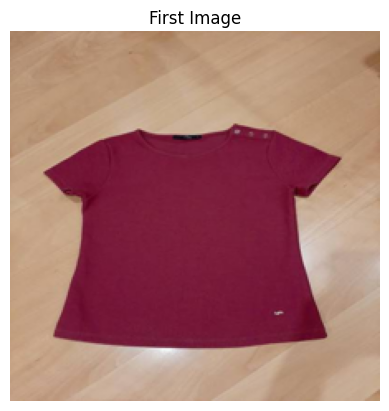

In [9]:
import matplotlib.pyplot as plt

first_image = df['image_data'].iloc[0]

plt.imshow(first_image)
plt.axis('off')
plt.title("First Image")
plt.show()

## Transform label from string to number

In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

df

,image,sender_id,label,kids,image_data,label_encoded
0,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False,"[[[170, 133, 104], [169, 132, 103], [167, 130,...",16
1,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False,"[[[183, 151, 121], [178, 147, 115], [180, 149,...",16
2,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False,"[[[207, 151, 90], [206, 150, 89], [207, 151, 9...",12
3,5d3a1404-697f-479f-9090-c1ecd0413d27,138,Shorts,False,"[[[210, 180, 146], [209, 179, 145], [208, 178,...",13
4,b0c03127-9dfb-4573-8934-1958396937bf,138,Shirt,False,"[[[208, 188, 156], [207, 187, 155], [208, 188,...",11
...,...,...,...,...,...,...
4841,dfd4079d-967b-4b3e-8574-fbac11b58103,204,Shorts,False,"[[[189, 188, 184], [191, 190, 186], [193, 192,...",13
4842,befa14be-8140-4faf-8061-1039947e329d,204,Body,True,"[[[91, 58, 41], [91, 59, 42], [89, 58, 40], [8...",2
4843,5379356a-40ee-4890-b416-2336a7d84061,310,Shorts,False,"[[[159, 159, 161], [163, 163, 165], [159, 159,...",13
4844,65507fb8-3456-4c15-b53e-d1b03bf71a59,204,Shoes,False,"[[[178, 177, 173], [179, 178, 174], [180, 179,...",12


## See the data distribution

In [11]:

for i, name in enumerate(df["label"].unique()):
    print(i, name, (df["label"] == name).count())


0 T-Shirt 4846
1 Shoes 4846
2 Shorts 4846
3 Shirt 4846
4 Pants 4846
5 Skirt 4846
6 Other 4846
7 Outwear 4846
8 Top 4846
9 Dress 4846
10 Body 4846
11 Longsleeve 4846
12 Undershirt 4846
13 Hat 4846
14 Polo 4846
15 Blouse 4846
16 Hoodie 4846
17 Skip 4846
18 Blazer 4846


We have exactly the same number of all categorie which is nice

## Useful function for prediction and accuracy

In [12]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib as plt
import seaborn as sns
import torch.nn as nn

def print_accuracy(y_test, y_pred):
    print("Absolute error:", (y_test != y_pred).sum())
    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("F1-scores (macro):", f1_score(y_test, y_pred, average='macro'))
    print("F1-scores (weighted):", f1_score(y_test, y_pred, average='weighted'))

    mat = confusion_matrix(y_test, y_pred)
    sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False)
    plt.xlabel('true label')
    plt.ylabel('predicted label')
    plt.tight_layout()  # Ensure everything fits well
    plt.show()

def get_pred(model: nn.Module, X_test):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)
    return y_pred

## Implementation of VGG

In [13]:
# code from https://www.youtube.com/watch?v=ACmuBbuXn20 Pytorch VGG implementation from scratch

VGG9 = [64, 'M', 128, 'M', 256, 'M', 512, 'M', 512, 512, 'M']
VGG11 = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M']
VGG16 = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M']

class VGG_net(nn.Module):
    def __init__(self, architecture, in_channels=3, num_classes=1000):
        super(VGG_net, self).__init__()
        self.in_channels = in_channels
        self.conv_layers = self.create_conv_layers(architecture)

        self.fcs = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(4096, num_classes),
            )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fcs(x)
        return x
        
    def create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if type(x) == int:
                out_channels = x
                layers.append(nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                                        kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)))
                layers.append(nn.BatchNorm2d(x))
                layers.append(nn.ReLU())
                in_channels = x
            elif x == 'M':
                layers.append(nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2)))
        return nn.Sequential(*layers)


## Implementation of ResNet
In the file ExperimentCNN we that that a basic CNN got ~50% accuracy on the same dataset. The best accuracy we got from VGG is 27.66% for VGG11. Hence maybe a network with residuals will get better result.

In [28]:
# code from https://www.youtube.com/watch?v=DkNIBBBvcPs, Pytorch ResNet implementation from Scratch

class block(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(block, self).__init__()
        self.expansion = 4

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels*self.expansion, kernel_size=1, stride=1, padding=0)
        self.bn3 = nn.BatchNorm2d(out_channels*self.expansion)
        self.relu = nn.ReLU()
        self.identity_downsample = identity_downsample
    
    def forward(self, x):
        identity = x.clone()

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.bn3(x)

        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)
        x += identity
        x = self.relu(x)
        return x

class ResNet(nn.Module):
    def __init__(self, block, layers, image_channels, num_classes):
        super(ResNet, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(image_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # ResNet layers
        self.layer1 = self._make_layer(block, layers[0], out_channels=64, stride=1)
        self.layer2 = self._make_layer(block, layers[1], out_channels=128, stride=2)
        self.layer3 = self._make_layer(block, layers[2], out_channels=256, stride=2)
        self.layer4 = self._make_layer(block, layers[2], out_channels=512, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512*4, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)

        return x

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []

        if stride != 1 or self.in_channels != out_channels * 4:
            identity_downsample = nn.Sequential(nn.Conv2d(self.in_channels, out_channels*4, kernel_size=1,
                                                          stride = stride),
                                                nn.BatchNorm2d(out_channels*4))
        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels*4

        for i in range(num_residual_blocks -1):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)
    
def ResNet50(img_channels=3, num_classes=1000):
    return ResNet(block, [3, 4, 6, 3], img_channels, num_classes)
        
def ResNet101(img_channels=3, num_classes=1000):
    return ResNet(block, [3, 4, 23, 3], img_channels, num_classes)

def ResNet152(img_channels=3, num_classes=1000):
    return ResNet(block, [3, 8, 36, 3], img_channels, num_classes)

In [ ]:
def test():
    net = ResNet50()
    x = torch.randn(2, 3, 224, 224)
    y = net(x).to('cpu')
    print(y.shape)
test()

torch.Size([2, 1000])


## Function to train the model

In [8]:
import torch.optim as optim
from tqdm import tqdm

def train_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu'):
    device = 'cpu'
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

        avg_loss = train_loss / total
        accuracy = 100.0 * correct / total
        print(f"Train Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

        # Optional: validate
        if val_loader is not None:
            model.eval()
            val_loss = 0
            correct = 0
            total = 0
            with torch.no_grad():
                for images, labels in val_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)

                    val_loss += loss.item() * images.size(0)
                    _, predicted = outputs.max(1)
                    correct += predicted.eq(labels).sum().item()
                    total += labels.size(0)

            avg_val_loss = val_loss / total
            val_accuracy = 100.0 * correct / total
            print(f"Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%")
    return model


## Create train test split

In [9]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from PIL import Image

# X = df["image_data"]
X = df["image_data"].apply(lambda img: np.transpose(img, (2, 0, 1)))
y = df["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8
)
print(X_train.values[0].shape)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(np.stack(X_train.values), dtype=torch.float32)  # Assuming X is NumPy array
X_test_tensor = torch.tensor(np.stack(X_test.values), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)  # CrossEntropy requires long tensor for labels
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

print(X_train_tensor[0].shape)

# Create TensorDataset objects
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# train_dataset = AugmentedImageDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoader objects
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


(3, 224, 224)
torch.Size([3, 224, 224])


## Try some VGG
Try VGG16, VGG11, VGG9, VGG11 pretrained

In [ ]:
# Define input shape and number of classes
input_shape = (224, 224, 3)
num_classes = 19  # 20 but I removed "Not sure"

# See if everything works
modeltest = VGG_net(VGG9, 3, num_classes)
modeltest = train_model(modeltest, train_loader, val_loader=test_loader, num_epochs=1)
y_predtest = get_pred(modeltest, X_test)
print_accuracy(y_test, y_predtest)

In [ ]:
# Initialize the model
model16 = VGG_net(VGG16, 3, num_classes)
model16 = train_model(model16, train_loader, val_loader=test_loader, num_epochs=10)

Epoch 1/10:   0%|          | 0/61 [00:33<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
y_pred16 = get_pred(model16, X_test)
print_accuracy(y_test, y_pred16)

In [ ]:
model11 = VGG_net(VGG11, 3, num_classes)
model11 = train_model(model11, train_loader, val_loader=test_loader, num_epochs=10)

Epoch 1/10: 100%|██████████| 61/61 [05:13<00:00,  5.14s/it]


Train Loss: 5.2388 | Accuracy: 15.35%
Val Loss: 2.6129 | Val Accuracy: 20.82%


Epoch 2/10: 100%|██████████| 61/61 [05:12<00:00,  5.13s/it]


Train Loss: 2.6221 | Accuracy: 18.24%
Val Loss: 2.5793 | Val Accuracy: 20.31%


Epoch 3/10: 100%|██████████| 61/61 [05:12<00:00,  5.12s/it]


...

Train Loss: 2.3714 | Accuracy: 26.88%
Val Loss: 2.3612 | Val Accuracy: 26.39%


Epoch 9/10: 100%|██████████| 61/61 [05:12<00:00,  5.12s/it]


Train Loss: 2.3614 | Accuracy: 27.66%
Val Loss: 2.3496 | Val Accuracy: 27.53%


Epoch 10/10: 100%|██████████| 61/61 [05:13<00:00,  5.13s/it]


Train Loss: 2.3720 | Accuracy: 27.32%
Val Loss: 2.3736 | Val Accuracy: 26.19%


In [ ]:
y_pred11 = get_pred(model11, X_test)
print_accuracy(y_test, y_pred11)

In [ ]:
model9 = VGG_net(VGG9, 3, num_classes)
model9 = train_model(model9, train_loader, val_loader=test_loader, num_epochs=10)

Epoch 1/10: 100%|██████████| 61/61 [03:32<00:00,  3.48s/it]


Train Loss: 5.5354 | Accuracy: 15.79%
Val Loss: 2.6077 | Val Accuracy: 19.69%


Epoch 2/10: 100%|██████████| 61/61 [03:31<00:00,  3.46s/it]


Train Loss: 2.6300 | Accuracy: 18.40%
Val Loss: 2.6206 | Val Accuracy: 15.98%


Epoch 3/10: 100%|██████████| 61/61 [03:31<00:00,  3.46s/it]


...

Train Loss: 2.5144 | Accuracy: 19.84%
Val Loss: 2.5570 | Val Accuracy: 17.73%


Epoch 9/10: 100%|██████████| 61/61 [03:30<00:00,  3.46s/it]


Train Loss: 2.5122 | Accuracy: 19.81%
Val Loss: 2.5525 | Val Accuracy: 17.73%


Epoch 10/10: 100%|██████████| 61/61 [03:30<00:00,  3.45s/it]


Train Loss: 2.5133 | Accuracy: 19.81%
Val Loss: 2.5552 | Val Accuracy: 17.73%


In [ ]:
y_pred9 = get_pred(model9, X_test)
print_accuracy(y_test, y_pred9)

In [ ]:
from torchvision import models

model_pre = models.vgg16(pretrained=True)

# Freeze weigth
for param in model_pre.features.parameters():
    param.requires_grad = False

# Change output layer
model_pre.classifier[6] = nn.Linear(4096, num_classes)
model_pre = train_model(model_pre, train_loader, val_loader=test_loader, num_epochs=10)

c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Utilisateur\Documents\GitHub\SlowFashionProject\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/10: 100%|██████████| 61/61 [02:05<00:00,  2.06s/it]


Train Loss: 4.6384 | Accuracy: 12.85%
Val Loss: 2.9149 | Val Accuracy: 13.30%


Epoch 2/10: 100%|██████████| 61/61 [02:04<00:00,  2.05s/it]


Train Loss: 2.9280 | Accuracy: 13.21%
Val Loss: 2.8838 | Val Accuracy: 13.40%


Epoch 3/10: 100%|██████████| 61/61 [02:04<00:00,  2.04s/it]


...

Train Loss: 2.8618 | Accuracy: 19.27%
Val Loss: 2.7310 | Val Accuracy: 17.73%


Epoch 9/10: 100%|██████████| 61/61 [02:03<00:00,  2.03s/it]


Train Loss: 2.7880 | Accuracy: 19.69%
Val Loss: 2.7132 | Val Accuracy: 17.73%


Epoch 10/10: 100%|██████████| 61/61 [02:04<00:00,  2.03s/it]


Train Loss: 2.7459 | Accuracy: 19.53%
Val Loss: 2.6969 | Val Accuracy: 17.73%


In [ ]:
y_pred_pre = get_pred(model_pre, X_test)
print_accuracy(y_test, y_pred_pre)

In [ ]:
from torchvision import models

model_pre_unfreeze = models.vgg11(pretrained=True)

# Freeze weigth
for param in model_pre_unfreeze.features.parameters():
    param.requires_grad = False

for i in [16, 18]:
    for param in model_pre_unfreeze.features[i].parameters():
        param.requires_grad = True

# # Change output layer
model_pre_unfreeze.classifier[6] = nn.Linear(4096, num_classes)
model_pre_unfreeze = train_model(model_pre_unfreeze, train_loader, val_loader=test_loader, num_epochs=10)

Epoch 1/10: 100%|██████████| 61/61 [02:22<00:00,  2.33s/it]


Train Loss: 3.0716 | Accuracy: 18.32%
Val Loss: 2.5667 | Val Accuracy: 17.73%


Epoch 2/10: 100%|██████████| 61/61 [02:21<00:00,  2.33s/it]


Train Loss: 2.5255 | Accuracy: 19.07%
Val Loss: 2.5667 | Val Accuracy: 17.73%


Epoch 3/10: 100%|██████████| 61/61 [02:21<00:00,  2.32s/it]


...

Train Loss: 2.5197 | Accuracy: 19.89%
Val Loss: 2.5617 | Val Accuracy: 17.73%


Epoch 9/10: 100%|██████████| 61/61 [02:20<00:00,  2.31s/it]


Train Loss: 2.5167 | Accuracy: 19.84%
Val Loss: 2.5557 | Val Accuracy: 17.73%


Epoch 10/10: 100%|██████████| 61/61 [02:21<00:00,  2.31s/it]


Train Loss: 2.5187 | Accuracy: 19.48%
Val Loss: 2.5676 | Val Accuracy: 17.73%


In [ ]:
y_pred_pre_unfreeze = get_pred(model_pre_unfreeze, X_test)
print_accuracy(y_test, y_pred_pre_unfreeze)

## Test ResNet

In [ ]:
model_resnet50 = ResNet50(img_channels=3, num_classes=num_classes)
model_resnet50 = train_model(model_resnet50, train_loader, val_loader=test_loader, num_epochs=10)
y_pred_resnet50= get_pred(model_resnet50, X_test)
print_accuracy(y_test, y_pred_resnet50)